In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import matplotlib.patches as patches
import matplotlib as mpl
from mplsoccer import Pitch, VerticalPitch, FontManager, Sbopen, add_image
from matplotlib.font_manager import FontProperties
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects
from highlight_text import ax_text, fig_text
from PIL import Image
from mplsoccer import add_image
from urllib.request import urlopen
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.ndimage import gaussian_filter


# Print the modified DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

green = '#69f900'
red = '#ff4b44'
blue = '#00a0de'
violet = '#a369ff'
bg_color= '#f5f5f5'
line_color= '#000000'
col1 = '#ff4b44'
col2 = '#00a0de'

In [2]:
df = pd.read_csv(r"D:\FData\All_Top_5_League\2024_25\event_data\Top5_League_2024_25_event_data.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_3468\1088915067.py:1: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\FData\All_Top_5_League\2024_25\event_data\Top5_League_2024_25_event_data.csv")


In [2]:
df = pd.read_csv(r"D:\FData\All_Top_5_League\Championship_2024_25\event_data\Championship_2024_25_event_data.csv")

C:\Users\h\AppData\Local\Temp\ipykernel_21600\3338163450.py:1: DtypeWarning: Columns (34,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\FData\All_Top_5_League\Championship_2024_25\event_data\Championship_2024_25_event_data.csv")


In [3]:
df = df[~df['type'].isin(['Carry', 'BallRecovery', 'GoodSkill', 'Aerial'])].reset_index(drop=True)

In [4]:
df_teamNameId = pd.read_csv(r"D:\FData\club_teams_logo\teams_name_and_id.csv")

In [25]:
player_database = pd.read_csv(r"D:\FData\All_Top_5_League\Championship_2024_25\player_database\Championship_player_position_df.csv")

In [7]:
font_path = "C:\Fonts\Montserrat_Alternates\MontserratAlternates-Bold.ttf"
custom_font = FontProperties(fname=font_path)
font_path_thin = "C:\Fonts\Montserrat_Alternates\MontserratAlternates-Regular.ttf"
custom_font_thin = FontProperties(fname=font_path_thin)

In [6]:
font_path = "C:\Fonts\Roboto_Condensed\static\RobotoCondensed-Bold.ttf"
custom_font = FontProperties(fname=font_path)
font_path_thin = "C:\Fonts\Roboto_Condensed\static\RobotoCondensed-Regular.ttf"
custom_font_thin = FontProperties(fname=font_path_thin)

# After TakeOn Actions

In [43]:
def positive_action(ax, pname):
    dfp = df[df['playerName']==pname]
    pteam = dfp.teamName.unique()[0]
    # dfteam = df[(df['teamName']==pteam) | (df['oppositionTeamName']==pteam)].reset_index(drop=True)
    dfteam = df[df['teamName']==pteam].reset_index(drop=True)

    pitch = VerticalPitch(pitch_type='uefa', pitch_color=bg_color,  linewidth=2, corner_arcs=True)
    pitch.draw(ax=ax)

    # Fouled
    fl = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Foul' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful'
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='None', edgecolor=col1, marker='s', ax=ax)
            fl += 1
    
    # Successful Pass
    sp = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' 
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color=col2, zorder=6, mutation_scale=15, alpha=0.75, linewidth=2)
            ax.add_patch(arrow)
            sp += 1

    # Key Pass
    kp = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'KeyPass' in dfteam.loc[index + 1, 'qualifiers']
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor=violet, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=violet, lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color=violet, zorder=6, mutation_scale=15, alpha=0.75, linewidth=2)
            ax.add_patch(arrow)
            kp += 1

    # Assist
    ass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'GoalAssist' in dfteam.loc[index + 1, 'qualifiers']
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor='green', ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color='green', lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color='green', zorder=6, mutation_scale=15, alpha=0.75, linewidth=2)
            ax.add_patch(arrow)
            ass += 1

    # Shots
    sht = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] in ['MissedShots', 'SavedShot', 'ShotOnPost']
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor='orange', ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color='orange', lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='orange', marker='^', ax=ax)
            sht += 1

    # Goals
    gl = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Goal'
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor='green', ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color='green', lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='green', marker='^', ax=ax)
            gl += 1

    
            

    ax.set_title('Positive Impact', fontproperties=custom_font, fontsize=15)
    ax_text(34, -8, f'<Successful Pass: {sp}> | <Key Pass: {kp}> | <Assist: {ass}>', ha='center', va='center', 
            highlight_textprops=[{'color': col2}, {'color': violet}, {'color': 'green'}], ax=ax, fontproperties=custom_font_thin, fontsize=15)
    ax_text(34, -4, f'<Shots: {sht}> | <Goals: {gl}> | <Fouls Won: {fl}>', ha='center', va='center', 
            highlight_textprops=[{'color': 'orange'}, {'color': 'green'}, {'color': col1}], ax=ax, fontproperties=custom_font_thin, fontsize=15)
    
    return

def negative_action(ax, pname):
    dfp = df[df['playerName']==pname]
    pteam = dfp.teamName.unique()[0]
    # dfteam = df[(df['teamName']==pteam) | (df['oppositionTeamName']==pteam)].reset_index(drop=True)
    dfteam = df[df['teamName']==pteam].reset_index(drop=True)

    pitch = VerticalPitch(pitch_type='uefa', pitch_color=bg_color,  linewidth=2, corner_arcs=True)
    pitch.draw(ax=ax)

    # Unsuccessful Pass
    up = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Unsuccessful' 
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color=col1, zorder=6, mutation_scale=15, alpha=0.75, linewidth=2)
            ax.add_patch(arrow)
            up += 1

    # Possession Lost
    pl = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and 
            row['type'] == 'TakeOn' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            (
                dfteam.loc[index + 1, 'type'] == 'Dispossessed' or 
                dfteam.loc[index + 1, 'type'] == 'BallTouch'
            )
        ):
            pitch.scatter(row['x'], row['y'], s=100, color='None', edgecolor=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='orange', marker='x', ax=ax)
            pl += 1

    ax.set_title('Negative Impact', fontproperties=custom_font, fontsize=15)
    ax_text(34, -4, f'<Unsuccessful Pass: {up}> | <Possession Lost: {pl}>', ha='center', va='center', 
            highlight_textprops=[{'color': col1}, {'color': 'orange'}], ax=ax, fontproperties=custom_font_thin, fontsize=15)
    ftmb_tid = df_teamNameId[df_teamNameId['teamName']==pteam].teamId.to_list()[0]
    return ftmb_tid

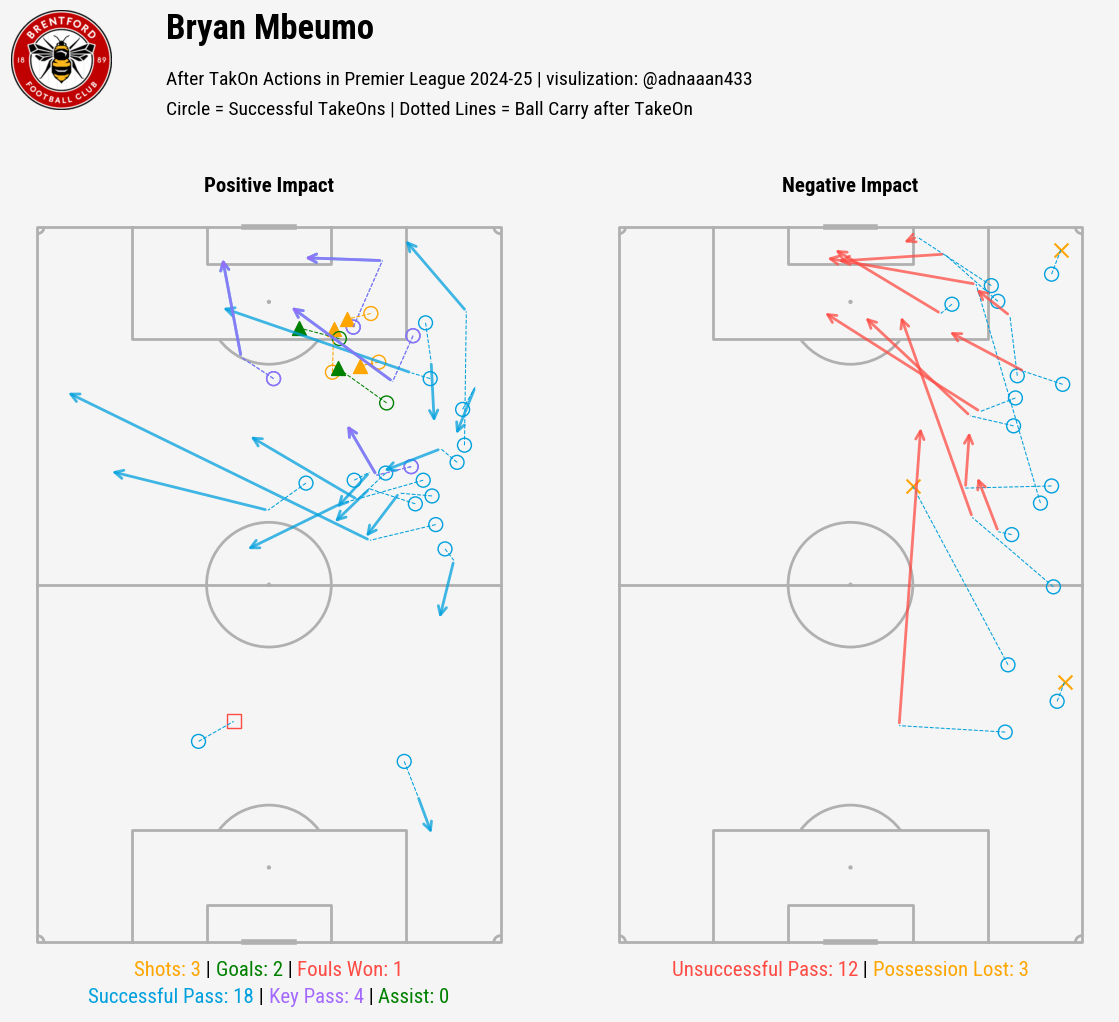

In [107]:
fig,axs = plt.subplots(1,2, figsize=(15,10), facecolor=bg_color)
pname = 'Bryan Mbeumo'
positive_action(axs[0], pname)
ftmb_tid = negative_action(axs[1], pname)
fig.subplots_adjust(wspace=0.001)

fig.text(0.25, 1.05, f'{pname}', fontsize=25, fontweight='bold', va='center', fontproperties=custom_font)
fig.text(0.25, 1.00, 'After TakOn Actions in Premier League 2024-25 | visulization: @adnaaan433', fontsize=14, va='center', fontproperties=custom_font_thin)
fig.text(0.25, 0.97, 'Circle = Successful TakeOns | Dotted Lines = Ball Carry after TakeOn', fontsize=14, va='center', fontproperties=custom_font_thin)

himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
himage = Image.open(himage)
ax_himage = add_image(himage, fig, left=0.13, bottom=0.97, width=0.1, height=0.1)

# Raw Function Detailed

In [6]:
def takeOnEff(pname, team_name):
    match_ids = df[df['playerName']==pname]['matchId'].unique()
    dfteam = df[(df['teamName']==team_name) & (df['matchId'].isin(match_ids))].reset_index(drop=True)
    dfteam = dfteam[['playerName', 'teamName', 'type', 'outcomeType', 'x', 'y', 'endX', 'endY', 'qualifiers', 'satisfiedEventsTypes']]

    pitch = Pitch(pitch_type='uefa')
    dims = pitch.dim

    penalty_area_right = dims.penalty_area_right
    penalty_area_bottom = dims.penalty_area_bottom
    penalty_area_top = dims.penalty_area_top
    pitch_length = dims.pitch_length

    '''
    Positive Actions
    '''

    #####################################################################################################################
    # Goal Threat
    # Goals (4 points)
    goal = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Goal'
        ):
            goal += 1

    # Shot On Target (3 points)
    shot_on_target = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            'shotOnTarget' in dfteam.loc[index + 1, 'satisfiedEventsTypes']
        ):
            shot_on_target += 1

    # Shot On Post (2 points)
    shot_on_post = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            'shotOnPost' in dfteam.loc[index + 1, 'satisfiedEventsTypes']
        ):
            shot_on_post += 1

    # Other Shots (1 point)
    other_shots = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] in ['MissedShots', 'SavedShot'] and
            'shotOnTarget' not in dfteam.loc[index + 1, 'satisfiedEventsTypes']
        ):
            other_shots += 1


    #####################################################################################################################
    # Chance Creating Threat
    # Assists (4 points)
    assist = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'GoalAssist' in dfteam.loc[index + 1, 'qualifiers']
        ):
            assist += 1

    # Big Chance Created (3 points)
    big_chance_created = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'bigChanceCreated' in dfteam.loc[index + 1, 'satisfiedEventsTypes']
        ):
            big_chance_created += 1

    # Key Pass (2 points)
    key_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'KeyPass' in dfteam.loc[index + 1, 'qualifiers'] and
            'bigChanceCreated' not in dfteam.loc[index + 1, 'satisfiedEventsTypes'] and
            'assist' not in dfteam.loc[index + 1, 'satisfiedEventsTypes']
        ):
            key_pass += 1

    # Pass in the box (1 point)
    pass_in_box = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            'KeyPass' not in dfteam.loc[index + 1, 'qualifiers'] and
            dfteam.loc[index + 1, 'x'] >= penalty_area_right and
            dfteam.loc[index + 1, 'y'] >= penalty_area_bottom and
            dfteam.loc[index + 1, 'y'] <= penalty_area_top
        ):
            pass_in_box += 1


    ########################################################################################################################################
    # Progression Threat
    # Def third to Final third Progression (3 points)
    def_to_final_third_non_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            row['x'] <= pitch_length * (1/3) and
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] not in ['Pass', 'BallTouch', 'Dispossessed'] and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'x'] >= pitch_length * (2/3) and
            np.sqrt((dfteam.loc[index + 1, 'x'] - row['x'])**2 + (dfteam.loc[index + 1, 'y'] - row['y'])**2) >= 10
        ):
            def_to_final_third_non_pass += 1

    def_to_final_third_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            row['x'] <= pitch_length * (1/3) and
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'endX'] >= pitch_length * (2/3) and
            np.sqrt((dfteam.loc[index + 1, 'endX'] - row['x'])**2 + (dfteam.loc[index + 1, 'endY'] - row['y'])**2) >= 10
        ):
            def_to_final_third_pass += 1

    # Mid third to Final third Progression (2 points)
    mid_to_final_third_non_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            row['x'] < pitch_length * (2/3) and
            row['x'] > pitch_length * (1/3) and
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] not in ['Pass', 'BallTouch', 'Dispossessed'] and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'x'] >= pitch_length * (2/3) and
            np.sqrt((dfteam.loc[index + 1, 'x'] - row['x'])**2 + (dfteam.loc[index + 1, 'y'] - row['y'])**2) >= 10
        ):
            mid_to_final_third_non_pass += 1

    mid_to_final_third_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            row['x'] < pitch_length * (2/3) and
            row['x'] > pitch_length * (1/3) and
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'endX'] >= pitch_length * (2/3) and
            np.sqrt((dfteam.loc[index + 1, 'endX'] - row['x'])**2 + (dfteam.loc[index + 1, 'endY'] - row['y'])**2) >= 10
        ):
            mid_to_final_third_pass += 1

    # Def third to Mid third Progression (1 point)
    def_to_mid_third_non_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            row['x'] <= pitch_length * (1/3) and
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] not in ['Pass', 'BallTouch', 'Dispossessed'] and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'x'] > pitch_length * (1/3) and
            dfteam.loc[index + 1, 'x'] < pitch_length * (2/3) and
            np.sqrt((dfteam.loc[index + 1, 'x'] - row['x'])**2 + (dfteam.loc[index + 1, 'y'] - row['y'])**2) >= 10
        ):
            def_to_mid_third_non_pass += 1

    def_to_mid_third_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            row['x'] <= pitch_length * (1/3) and
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'endX'] > pitch_length * (1/3) and
            dfteam.loc[index + 1, 'endX'] < pitch_length * (2/3) and
            np.sqrt((dfteam.loc[index + 1, 'endX'] - row['x'])**2 + (dfteam.loc[index + 1, 'endY'] - row['y'])**2) >= 10
        ):
            def_to_mid_third_pass += 1

    #####################################################################################################################
    # Ball Retention Threat
    # Fouled in Final third (3 points)
    fouled_in_final_third = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Foul' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'x'] >= pitch_length * (2/3)
        ):
            fouled_in_final_third += 1

    # Fouled in Mid third (2 points)
    fouled_in_mid_third = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Foul' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'x'] < pitch_length * (2/3) and
            dfteam.loc[index + 1, 'x'] > pitch_length * (1/3)
        ):
            fouled_in_mid_third += 1

    # Fouled in Def third (1 point)
    fouled_in_def_third = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Foul' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' and
            dfteam.loc[index + 1, 'x'] <= pitch_length * (1/3)
        ):
            fouled_in_def_third += 1

    #####################################################################################################################
    # Possession Lost in Final third (-1 point)
    possession_lost_in_final_third_non_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] in ['BallTouch', 'Dispossessed'] and
            dfteam.loc[index + 1, 'x'] >= pitch_length * (2/3)
        ):
            possession_lost_in_final_third_non_pass += 1

    possession_lost_in_final_third_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Unsuccessful' and
            dfteam.loc[index + 1, 'endX'] >= pitch_length * (2/3)
        ):
            possession_lost_in_final_third_pass += 1

    # Possession Lost in Mid third (-2 points)
    possession_lost_in_mid_third_non_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] in ['BallTouch', 'Dispossessed'] and
            dfteam.loc[index + 1, 'x'] < pitch_length * (2/3) and
            dfteam.loc[index + 1, 'x'] > pitch_length * (1/3)
        ):
            possession_lost_in_mid_third_non_pass += 1

    possession_lost_in_mid_third_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Unsuccessful' and
            dfteam.loc[index + 1, 'endX'] < pitch_length * (2/3) and
            dfteam.loc[index + 1, 'endX'] > pitch_length * (1/3)
        ):
            possession_lost_in_mid_third_pass += 1

    # Possession Lost in Def third (-3 points)
    possession_lost_in_def_third_non_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] in ['BallTouch', 'Dispossessed'] and
            dfteam.loc[index + 1, 'x'] <= pitch_length * (1/3)
        ):
            possession_lost_in_def_third_non_pass += 1

    # possession_lost_in_def_third_pass = 0
    possession_lost_in_def_third_pass = 0
    for index, row in dfteam.iterrows():
        if (
            row['playerName'] == pname and row['type'] == 'TakeOn' and row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'playerName'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Unsuccessful' and
            dfteam.loc[index + 1, 'endX'] <= pitch_length * (1/3)
        ):
            possession_lost_in_def_third_pass += 1


    return {
        'Name': pname,
        'Team': team_name,
        # Goal Threat
        'Goals': goal,
        'Shots_On_Target': shot_on_target,
        'Shots_On_Post': shot_on_post,
        'Other_Shots': other_shots,

        # Chance Creating Threat
        'Assists': assist,
        'Big_Chances_Created': big_chance_created,
        'Key_Pass': key_pass,
        'Pass_In_Box': pass_in_box,

        # Progression Threat
        'Progression_Def_To_Final_Third': def_to_final_third_non_pass + def_to_final_third_pass,
        'Progression_Mid_To_Final_Third': mid_to_final_third_non_pass + mid_to_final_third_pass,
        'Progression_Def_To_Mid_Third': def_to_mid_third_non_pass + def_to_mid_third_pass,

        # Ball Retention Threat
        'Fouled_In_Final_Third': fouled_in_final_third,
        'Fouled_In_Mid_Third': fouled_in_mid_third,
        'Fouled_In_Def_Third': fouled_in_def_third,

        # Possession Lost
        'Possession_Lost_In_Final_Third': possession_lost_in_final_third_non_pass + possession_lost_in_final_third_pass,
        'Possession_Lost_In_Mid_Third': possession_lost_in_mid_third_non_pass + possession_lost_in_mid_third_pass,
        'Possession_Lost_In_Def_Third': possession_lost_in_def_third_non_pass + possession_lost_in_def_third_pass,

    }

# Advanced Function (Faster)

In [7]:
import numpy as np
from collections import defaultdict

def takeOnEff(pname, team_name):
    # Pre-filter data once
    match_ids = df[df['playerName'] == pname]['matchId'].unique()
    dfteam = df[(df['teamName'] == team_name) & (df['matchId'].isin(match_ids))].reset_index(drop=True)
    dfteam = dfteam[['playerName', 'teamName', 'type', 'outcomeType', 'x', 'y', 'endX', 'endY', 'qualifiers', 'satisfiedEventsTypes']]
    total_take_ons = len(dfteam[(dfteam['playerName'] == pname) & (dfteam['teamName']==team_name) & (dfteam['type'] == 'TakeOn')])
    successful_take_ons = len(dfteam[(dfteam['playerName'] == pname) & (dfteam['teamName']==team_name) & (dfteam['type'] == 'TakeOn') & (dfteam['outcomeType'] == 'Successful')])

    # Get pitch dimensions once
    pitch = Pitch(pitch_type='uefa')
    dims = pitch.dim
    penalty_area_right = dims.penalty_area_right
    penalty_area_bottom = dims.penalty_area_bottom
    penalty_area_top = dims.penalty_area_top
    pitch_length = dims.pitch_length
    
    # Pre-calculate thirds
    third_1 = pitch_length * (1/3)
    third_2 = pitch_length * (2/3)

    # Initialize counters
    metrics = defaultdict(int)
    
    # Convert to numpy arrays for faster access
    player_names = dfteam['playerName'].values
    types = dfteam['type'].values
    outcome_types = dfteam['outcomeType'].values
    x_coords = dfteam['x'].values
    y_coords = dfteam['y'].values
    end_x_coords = dfteam['endX'].values
    end_y_coords = dfteam['endY'].values
    qualifiers = dfteam['qualifiers'].values
    satisfied_events = dfteam['satisfiedEventsTypes'].values
    
    # Single pass through the data
    for i in range(len(dfteam) - 2):  # Changed to -2 to handle i+2 safely
        # Check if current row is a successful take-on by our player
        if (player_names[i] == pname and 
            types[i] == 'TakeOn' and 
            outcome_types[i] == 'Successful'):
            
            # Find the next meaningful action by same player (skip consecutive TakeOns)
            next_i = i + 1
            
            # If next action is also a TakeOn by same player, look at i+2
            while (next_i < len(dfteam) and 
                   player_names[next_i] == pname and 
                   types[next_i] == 'TakeOn' and 
                   outcome_types[next_i] == 'Successful'):
                next_i += 1
            
            # Make sure we don't go out of bounds and it's still the same player
            if next_i < len(dfteam) and player_names[next_i] == pname:
                next_type = types[next_i]
                next_outcome = outcome_types[next_i]
                next_x = x_coords[next_i]
                next_y = y_coords[next_i]
                next_end_x = end_x_coords[next_i]
                next_end_y = end_y_coords[next_i]
                next_qualifiers = qualifiers[next_i] if qualifiers[next_i] is not None else ""
                next_satisfied = satisfied_events[next_i] if satisfied_events[next_i] is not None else ""
                
                current_x = x_coords[i]
                current_y = y_coords[i]
                
                # Goal Threat
                if next_type == 'Goal':
                    metrics['goal'] += 1
                elif ('shotOnTarget' in str(next_satisfied) and next_type != 'Goal'):
                    metrics['shot_on_target'] += 1
                elif next_type == 'ShotOnPost':
                    metrics['shot_on_post'] += 1
                elif (next_type in ['MissedShots', 'SavedShot'] and 
                      'shotOnTarget' not in str(next_satisfied)):
                    metrics['other_shots'] += 1
                
                # Chance Creation
                elif next_type == 'Pass':
                    if 'GoalAssist' in str(next_qualifiers):
                        metrics['assist'] += 1
                    elif ('bigChanceCreated' in str(next_satisfied) and 'GoalAssist' not in str(next_qualifiers)):
                        metrics['big_chance_created'] += 1
                    elif ('KeyPass' in str(next_qualifiers) and 
                          'bigChanceCreated' not in str(next_satisfied) and
                          'assist' not in str(next_satisfied)):
                        metrics['key_pass'] += 1
                    elif (next_outcome == 'Successful' and
                          'KeyPass' not in str(next_qualifiers) and
                          next_end_x >= penalty_area_right and
                          penalty_area_bottom <= next_end_y <= penalty_area_top):
                        metrics['pass_in_box'] += 1
                    
                    # Check for possession lost via unsuccessful pass
                    if next_outcome == 'Unsuccessful':
                        if next_end_x >= third_2:
                            metrics['possession_lost_in_final_third'] += 1
                        elif third_1 < next_end_x < third_2:
                            metrics['possession_lost_in_mid_third'] += 1
                        elif next_end_x <= third_1:
                            metrics['possession_lost_in_def_third'] += 1
                
                # Ball Retention - Getting fouled
                elif next_type == 'Foul' and next_outcome == 'Successful':
                    if next_x >= third_2:
                        metrics['fouled_in_final_third'] += 1
                    elif third_1 < next_x < third_2:
                        metrics['fouled_in_mid_third'] += 1
                    elif next_x <= third_1:
                        metrics['fouled_in_def_third'] += 1
                
                # Possession lost via dispossession/ball touch
                elif next_type in ['BallTouch', 'Dispossessed']:
                    if next_x >= third_2:
                        metrics['possession_lost_in_final_third'] += 1
                    elif third_1 < next_x < third_2:
                        metrics['possession_lost_in_mid_third'] += 1
                    elif next_x <= third_1:
                        metrics['possession_lost_in_def_third'] += 1
                
                # Progression checks (for non-pass actions)
                elif (next_type not in ['Pass', 'BallTouch', 'Dispossessed'] and 
                      next_outcome == 'Successful'):
                    
                    distance = np.sqrt((next_x - current_x)**2 + (next_y - current_y)**2)
                    if distance >= 10 and next_x > current_x + 2.5:
                        # Def to Final third
                        if current_x <= third_1 and next_x >= third_2:
                            metrics['def_to_final_third'] += 1
                        # Mid to Final third
                        elif third_1 < current_x < third_2 and next_x >= third_2:
                            metrics['mid_to_final_third'] += 1
                        # Def to Mid third
                        elif current_x <= third_1 and third_1 < next_x < third_2:
                            metrics['def_to_mid_third'] += 1
                
                # Progression checks for passes
                if next_type == 'Pass' and next_outcome == 'Successful':
                    distance = np.sqrt((next_end_x - current_x)**2 + (next_end_y - current_y)**2)
                    if distance >= 10 and next_end_x > current_x + 2.5:
                        # Def to Final third
                        if current_x <= third_1 and next_end_x >= third_2:
                            metrics['def_to_final_third'] += 1
                        # Mid to Final third
                        elif third_1 < current_x < third_2 and next_end_x >= third_2:
                            metrics['mid_to_final_third'] += 1
                        # Def to Mid third
                        elif current_x <= third_1 and third_1 < next_end_x < third_2:
                            metrics['def_to_mid_third'] += 1

    return {
        'playerName': pname,
        'teamName': team_name,
        'Total_TakeOns': total_take_ons,
        'Successful_TakeOns': successful_take_ons,
        # Goal Threat
        'Goals': metrics['goal'],
        'Shots_On_Target': metrics['shot_on_target'],
        'Shots_On_Post': metrics['shot_on_post'],
        'Other_Shots': metrics['other_shots'],

        # Chance Creating Threat
        'Assists': metrics['assist'],
        'Big_Chances_Created': metrics['big_chance_created'],
        'Key_Pass': metrics['key_pass'],
        'Pass_In_Box': metrics['pass_in_box'],

        # Progression Threat
        'Progression_Def_To_Final_Third': metrics['def_to_final_third'],
        'Progression_Mid_To_Final_Third': metrics['mid_to_final_third'],
        'Progression_Def_To_Mid_Third': metrics['def_to_mid_third'],

        # Ball Retention Threat
        'Fouled_In_Final_Third': metrics['fouled_in_final_third'],
        'Fouled_In_Mid_Third': metrics['fouled_in_mid_third'],
        'Fouled_In_Def_Third': metrics['fouled_in_def_third'],

        # Possession Lost
        'Possession_Lost_In_Final_Third': metrics['possession_lost_in_final_third'],
        'Possession_Lost_In_Mid_Third': metrics['possession_lost_in_mid_third'],
        'Possession_Lost_In_Def_Third': metrics['possession_lost_in_def_third'],
    }

In [9]:
# striker = ['FW', 'FWL', 'FWR', 'AML', 'AMR']
# midfield = ['AMC', 'MC', 'ML', 'MR', 'DMC']
# defender = ['DC', 'DL', 'DR', 'DML', 'DMR']

In [38]:
striker = ['FW', 'FWL', 'FWR', 'AMC', 'AML', 'AMR']
mid_def = ['MC', 'ML', 'MR', 'DMC', 'DL', 'DR', 'DML', 'DMR']
fullback = ['DL', 'DR', 'DML', 'DMR']

In [10]:
# Filter for successful take-ons
successful_takeons = df[(df['type'] == 'TakeOn') & (df['outcomeType'] == 'Successful')]

# Group by player name and team name, then count occurrences
player_team_counts = successful_takeons.groupby(['playerName', 'teamName']).size().reset_index(name='successful_takeons_count')

# Get players with at least 10 successful take-ons
players_with_10_plus = player_team_counts[player_team_counts['successful_takeons_count'] >= 10]

all_player_data = []

# Loop through each row of the players_with_10_plus DataFrame
# to get the player name and their corresponding team name.
for index, row in players_with_10_plus.iterrows():
    player_name = row['playerName']
    team_name = row['teamName']

    player_data = takeOnEff(player_name, team_name)
    if player_data:  # Check if data exists (not an empty dictionary)
        # Convert dictionary to a DataFrame
        player_df = pd.DataFrame([player_data])
        all_player_data.append(player_df)

# Concatenate all player DataFrames into a single DataFrame
if all_player_data:
    pdf = pd.concat(all_player_data, ignore_index=True)
else:
    pdf = pd.DataFrame() 

pdf = pdf.sort_values(by='Total_TakeOns', ascending=False).reset_index(drop=True)

rating = pd.DataFrame()
rating['playerName'] = pdf['playerName']
rating['teamName'] = pdf['teamName']
# rating['Successful_Take_Ons'] = pdf['Successful_TakeOns']

rating['Goal_Threat'] = pdf['Goals'] * 8 + pdf['Shots_On_Post'] * 4 + pdf['Shots_On_Target'] * 2 + pdf['Other_Shots'] * 1
rating['Chance_Creating_Threat'] = pdf['Assists'] * 8 + pdf['Big_Chances_Created'] * 4 + pdf['Key_Pass'] * 2 + pdf['Pass_In_Box'] * 1
rating['Progression_Threat'] = pdf['Progression_Def_To_Final_Third'] * 4 + pdf['Progression_Mid_To_Final_Third'] * 2 + pdf['Progression_Def_To_Mid_Third'] * 1
rating['Ball_Retention_Threat'] = (pdf['Successful_TakeOns'] * 1) - ((pdf['Possession_Lost_In_Final_Third'] * 1) +
                                                                     (pdf['Possession_Lost_In_Mid_Third'] * 2) +
                                                                     (pdf['Possession_Lost_In_Def_Third'] * 4) )

rating = rating.merge(player_database[['playerName', 'teamName', 'primaryPosition', 'secondaryPosition', 'playing_time']], 
                on=['playerName', 'teamName'], 
                how='left')

condition1 = rating['playing_time'] >= 500
condition2 = rating['primaryPosition'].isin(fullback)
condition3 = (rating['primaryPosition'] == 'Sub') & (rating['secondaryPosition'].isin(fullback))

rating = rating[condition1 & (condition2 | condition3)].reset_index(drop=True)
# rating['Successful_Take_Ons_p90'] = (rating['Successful_Take_Ons'] / rating['playing_time']) * 90
rating['Goal_Threat_p90'] = (rating['Goal_Threat'] / rating['playing_time']) * 90
rating['Chance_Creating_Threat_p90'] = (rating['Chance_Creating_Threat'] / rating['playing_time']) * 90
rating['Progression_Threat_p90'] = (rating['Progression_Threat'] / rating['playing_time']) * 90
rating['Ball_Retention_Threat_p90'] = (rating['Ball_Retention_Threat'] / rating['playing_time']) * 90


# Create percentile dataframe
percentile_data = {
    'playerName': rating['playerName'].copy(),
    'teamName': rating['teamName'].copy(),
    'playing_time': rating['playing_time'].copy(),
}

# Calculate percentiles for each threat column
threat_columns = ['Goal_Threat_p90', 'Chance_Creating_Threat_p90', 'Progression_Threat_p90', 
                  'Ball_Retention_Threat_p90'
                  ]

for col in threat_columns:
    # Calculate percentile rank (0-100 scale)
    percentile_data[f'{col}_Percentile'] = rating[col].rank(pct=True) * 100

# Calculate average percentile across all four threat metrics
percentile_cols = [f'{col}_Percentile' for col in threat_columns]
percentile_data['Final_Percentile'] = np.mean([percentile_data[col] for col in percentile_cols], axis=0)

# Create the percentile dataframe
percentile_df = pd.DataFrame(percentile_data)

# Round percentiles to 2 decimal places for better readability
for col in percentile_cols + ['Final_Percentile']:
    percentile_df[col] = percentile_df[col].round(2)

# Sort by Final Percentile
percentile_df = percentile_df.sort_values(by='Final_Percentile', ascending=False).reset_index(drop=True)
for col in percentile_cols + ['Final_Percentile']:
    percentile_df[col] = percentile_df[col].round().astype(int)
percentile_df.head(50)

,playerName,teamName,playing_time,Goal_Threat_p90_Percentile,Chance_Creating_Threat_p90_Percentile,Progression_Threat_p90_Percentile,Ball_Retention_Threat_p90_Percentile,Final_Percentile
0,Conor Bradley,Liverpool,766,98,100,97,90,96
1,Nuno Tavares,Lazio,1681,90,92,98,94,93
2,Andrei Ratiu,Rayo Vallecano,3065,73,94,99,100,91
3,Diego Moreira,Strasbourg,2569,80,99,84,96,90
4,Djed Spence,Tottenham,1813,75,96,96,90,89
5,Nuno Mendes,PSG,1682,77,87,96,92,88
6,Alphonso Davies,Bayern,1559,61,93,93,99,86
7,Yan Couto,Borussia Dortmund,901,95,57,95,95,85
8,Dilane Bakwa,Strasbourg,2490,96,80,70,93,85
9,Rayan Aït-Nouri,Wolves,3114,83,74,83,98,84


In [11]:
def takeOnEffViz(ax, pname, team_name):
    all_to = df[(df['playerName'] == pname) & (df['teamName'] == team_name) & (df['type'] == 'TakeOn')]
    tos = all_to[all_to['outcomeType']=='Successful']
    tou = all_to[all_to['outcomeType']=='Unsuccessful']
    sret = round((len(tos)/len(all_to))*100, 2)

    pitch = VerticalPitch(pitch_type='uefa', pitch_color=bg_color, line_color=line_color, linewidth=2, line_zorder=3)
    pitch.draw(ax=ax)
    
    
    flamingo_cmap = LinearSegmentedColormap.from_list("Flamingo - 100 colors", [bg_color, 'green'], N=250)
    # pitch.kdeplot(tos.x, tos.y, cmap=flamingo_cmap, ax=ax, alpha=1, levels=100, fill=True, thresh=0.02, cut=4)
    bin_statistic = pitch.bin_statistic(all_to.x, all_to.y, statistic='count', bins=(27, 18))
    bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
    pitch.heatmap(bin_statistic, ax=ax, cmap=flamingo_cmap, edgecolors='None', alpha=1)

    # ax.scatter(tos.y, tos.x, marker='o', color='None', edgecolor=col2)
    # ax.scatter(tou.y, tou.x, marker='x', color=col1)

    ax.set_title('Take-On Heatmap', fontproperties=custom_font, fontsize=15, fontweight='bold', color='black')
    ax.text(34, -4, f'Successful Take-Ons: {len(tos)}  |  Success Rate: {sret}%', fontproperties=custom_font_thin, ha='center', va='bottom')


def rating_viz(ax, pname, team_name):
    rating_df = percentile_df[(percentile_df['playerName'] == pname) & (percentile_df['teamName'] == team_name)]
    overall_rating = rating_df['Final_Percentile'].values[0] if not rating_df.empty else 0
    
    if rating_df.empty:
        return
    
    # Define metrics and their labels
    metrics = [
        ('Ball_Retention_Threat_p90_Percentile', 'Ball Retention'),
        ('Progression_Threat_p90_Percentile', 'Progression Threat'),
        ('Chance_Creating_Threat_p90_Percentile', 'Playmaking Threat'),
        ('Goal_Threat_p90_Percentile', 'Scoring Threat'),
    ]
    
    # Extract values and create color map
    values = [rating_df[metric].values[0] for metric, _ in metrics]
    labels = [label for _, label in metrics]
    
    # Create colormap from red to green
    cmap = mcolors.LinearSegmentedColormap.from_list("", [col1, 
                                                          "orange", 
                                                          "green"])
    colors = [cmap(value / 100) for value in values]  # Assuming percentiles are 0-100
    
    # Create horizontal bars
    y_positions = range(len(metrics))
    # Add gray background bars (full width)
    ax.barh(y_positions, [100] * len(metrics), color='gray', alpha=0.5, height=0.5)
    ax.barh(y_positions, values, color=colors, height=0.5)

    # Add circular scatter points with value text
    for i, (y_pos, value) in enumerate(zip(y_positions, values)):
        # Add scatter point at the end of each bar
        ax.scatter(110, y_pos, s=400, c=[colors[i]], edgecolor='None', alpha=0.25, linewidth=2, zorder=10)
        
        # Add value text inside the circle
        ax.text(110, y_pos, f'{value:.0f}', ha='center', va='center', 
                color='black', fontproperties=custom_font_thin, fontsize=8.5, zorder=11)
    
    # Set labels
    ax.set_yticks(y_positions)
    ax.tick_params(axis='y', length=0)
    ax.set_yticklabels(labels, fontproperties=custom_font_thin, fontsize=12)
    # ax.set_xlabel('Percentile')
    ax.set_xlim(-35, 120) 
    ax.set_ylim(-5, 4)
    # Move y-labels further from the bars
    ax.tick_params(axis='y', pad=-50)
    # Turn off spines and x ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_facecolor(bg_color)
    ax.set_title('After Take-On Threats', fontproperties=custom_font, fontsize=15, fontweight='bold', color='black')

    ax.text(-55, -1.5, '- Scoring Threat: Player takes Shots after Successful Take-Ons', fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    ax.text(-55, -2, '- Playmaking Threat: Player Creates Chances after Successful Take-Ons', fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    ax.text(-55, -2.5, '- Progression Threat: Player Progress the ball after Successful Take-Ons', fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    ax.text(-55, -3, "- Ball Retention: Player Doesn't lose possession after Successful Take-Ons", fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    ax.text(-55, -3.5, "- Comparing Players with 500+ mins & 10+ Successful Take-Ons", fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    ax.text(-55, -4, "Data: Opta  |  Visuals by: @adnaaan433", fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')

    return overall_rating


TypeError: unsupported operand type(s) for /: 'NoneType' and 'int'

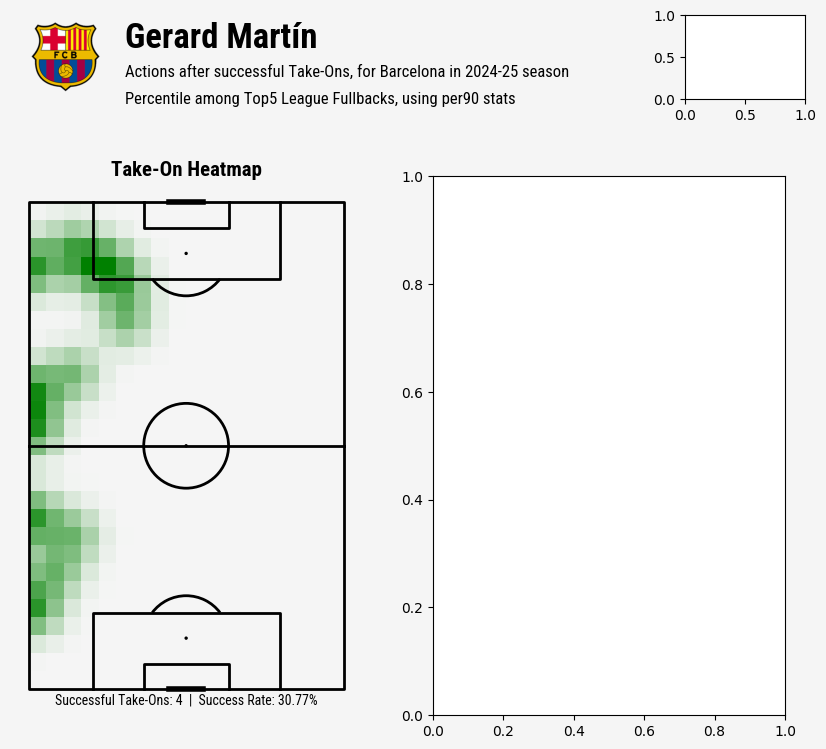

In [23]:
fig, axs = plt.subplots(1,2, figsize=(10, 7), facecolor=bg_color)
pname = 'Gerard Martín'
team_name = 'Barcelona'


takeOnEffViz(axs[0], pname, team_name)
overall_rating = rating_viz(axs[1], pname, team_name)

fig.text(0.24, 1.1, f'{pname}', fontproperties=custom_font, fontsize=25, fontweight='bold', color='black', ha='left', va='top')
fig.text(0.24, 1.04, f'Actions after successful Take-Ons, for {team_name} in 2024-25 season', fontproperties=custom_font_thin, fontsize=12, fontweight='bold', color='black', ha='left', va='top')
fig.text(0.24, 1, 'Percentile among Top5 League Fullbacks, using per90 stats', fontproperties=custom_font_thin, fontsize=12, fontweight='bold', color='black', ha='left', va='top')

ftmb_tid = df_teamNameId[df_teamNameId['teamName']==team_name].teamId.to_list()[0]
himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
himage = Image.open(himage)
ax_himage = add_image(himage, fig, left=0.13, bottom=1, width=0.1, height=0.1)

# Add small square axis at top right corner
corner_ax = fig.add_axes([0.8, 0.99, 0.12, 0.12])

# Create colormap for the scatter point
cmap = mcolors.LinearSegmentedColormap.from_list("", [col1, 
                                                      "orange",
                                                      "green"])
scatter_color = cmap(overall_rating / 100)  # Assuming percentiles are 0-100

# Add scatter point behind the text
corner_ax.scatter(0.5, 0.5, s=3000, c=[scatter_color], edgecolors='None', 
                 linewidth=3, transform=corner_ax.transAxes, zorder=1)

# Add text on top of scatter
corner_ax.text(0.5, 0.5, f'{overall_rating:.0f}', ha='center', va='center', 
               fontproperties=custom_font, fontsize=25, 
               transform=corner_ax.transAxes, color='white', fontweight='bold', zorder=2)

# Remove axis elements
corner_ax.set_xticks([])
corner_ax.set_yticks([])
corner_ax.set_facecolor(bg_color)
for spine in corner_ax.spines.values():
    spine.set_visible(False)

In [24]:
import os

# SET YOUR DIRECTORY PATH HERE
output_dir = r"D:\\FData\All_Top_5_League\\2024_25\Analysis\\After_Take_On_Threat\\Fullbacks"  # Paste your directory path between the quotes
os.makedirs(output_dir, exist_ok=True)

# Get unique players from percentile_df
unique_players = percentile_df[['playerName', 'teamName']].drop_duplicates()

print(f"Generating reports for {len(unique_players)} unique players...")

# Loop through each unique player
for idx, row in unique_players.iterrows():
    pname = row['playerName']
    team_name = row['teamName']
    
    print(f"Processing {pname} ({team_name})...")
    
    try:
        # Create figure
        fig, axs = plt.subplots(1, 2, figsize=(10, 7), facecolor=bg_color)
        
        # Generate visualizations
        takeOnEffViz(axs[0], pname, team_name)
        overall_rating = rating_viz(axs[1], pname, team_name)
        
        # Add title and subtitle text
        fig.text(0.24, 1.1, f'{pname}', fontproperties=custom_font, fontsize=25, 
                fontweight='bold', color='black', ha='left', va='top')
        fig.text(0.24, 1.04, f'Actions after successful Take-Ons, for {team_name} in 2024-25 season', 
                fontproperties=custom_font_thin, fontsize=12, fontweight='bold', 
                color='black', ha='left', va='top')
        fig.text(0.24, 1, 'Percentile among Top5 League Fullbacks, using per90 stats', 
                fontproperties=custom_font_thin, fontsize=12, fontweight='bold', 
                color='black', ha='left', va='top')
        
        # Add team logo
        try:
            ftmb_tid = df_teamNameId[df_teamNameId['teamName']==team_name].teamId.to_list()[0]
            himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
            himage = Image.open(himage)
            ax_himage = add_image(himage, fig, left=0.13, bottom=1, width=0.1, height=0.1)
        except:
            print(f"Warning: Could not load team logo for {team_name}")
        
        # Add small square axis at top right corner with overall rating
        corner_ax = fig.add_axes([0.8, 0.99, 0.12, 0.12])
        
        # Create colormap for the scatter point
        cmap = mcolors.LinearSegmentedColormap.from_list("", [col1, "orange", "green"])
        scatter_color = cmap(overall_rating / 100)  # Assuming percentiles are 0-100
        
        # Add scatter point behind the text
        corner_ax.scatter(0.5, 0.5, s=3000, c=[scatter_color], edgecolors='None', 
                         linewidth=3, transform=corner_ax.transAxes, zorder=1)
        
        # Add text on top of scatter
        corner_ax.text(0.5, 0.5, f'{overall_rating:.0f}', ha='center', va='center', 
                       fontproperties=custom_font, fontsize=25, 
                       transform=corner_ax.transAxes, color='white', fontweight='bold', zorder=2)
        
        # Remove axis elements
        corner_ax.set_xticks([])
        corner_ax.set_yticks([])
        corner_ax.set_facecolor(bg_color)
        for spine in corner_ax.spines.values():
            spine.set_visible(False)
        
        # Save the figure
        # Create safe filename by replacing special characters
        safe_pname = "".join(c for c in pname if c.isalnum() or c in (' ', '-', '_')).rstrip()
        safe_team_name = "".join(c for c in team_name if c.isalnum() or c in (' ', '-', '_')).rstrip()
        filename = f"{safe_pname}_{safe_team_name}_report.png"
        filepath = os.path.join(output_dir, filename)
        
        # Save with high DPI for quality
        fig.savefig(filepath, dpi=100, bbox_inches='tight', facecolor=bg_color)
        
        # Close figure to free memory
        plt.close(fig)
        
        print(f"✓ Saved: {filename}")
        
    except Exception as e:
        print(f"✗ Error processing {pname} ({team_name}): {str(e)}")
        continue

print(f"\nCompleted! All player reports saved to '{output_dir}' directory.")
print(f"Generated {len([f for f in os.listdir(output_dir) if f.endswith('.png')])} PNG files.")

Generating reports for 166 unique players...
Processing Conor Bradley (Liverpool)...
✓ Saved: Conor Bradley_Liverpool_report.png
Processing Nuno Tavares (Lazio)...
✓ Saved: Nuno Tavares_Lazio_report.png
Processing Andrei Ratiu (Rayo Vallecano)...
✓ Saved: Andrei Ratiu_Rayo Vallecano_report.png
Processing Diego Moreira (Strasbourg)...
✓ Saved: Diego Moreira_Strasbourg_report.png
Processing Djed Spence (Tottenham)...
✓ Saved: Djed Spence_Tottenham_report.png
Processing Nuno Mendes (PSG)...
✓ Saved: Nuno Mendes_PSG_report.png
Processing Alphonso Davies (Bayern)...
✓ Saved: Alphonso Davies_Bayern_report.png
Processing Yan Couto (Borussia Dortmund)...
✓ Saved: Yan Couto_Borussia Dortmund_report.png
Processing Dilane Bakwa (Strasbourg)...
✓ Saved: Dilane Bakwa_Strasbourg_report.png
Processing Rayan Aït-Nouri (Wolves)...
✓ Saved: Rayan Aït-Nouri_Wolves_report.png
Processing Julian Ryerson (Borussia Dortmund)...
✓ Saved: Julian Ryerson_Borussia Dortmund_report.png
Processing Aaron Wan-Bissaka 

# Using xG, xAG, xT

In [38]:
import numpy as np
from collections import defaultdict

def takeOnEff_x(pname, team_name):
    # Pre-filter data once
    match_ids = df[df['playerName'] == pname]['matchId'].unique()
    dfteam = df[(df['teamName'] == team_name) & (df['matchId'].isin(match_ids))].reset_index(drop=True)
    dfteam = dfteam[['playerName', 'teamName', 'type', 'outcomeType', 'x', 'y', 'endX', 'endY', 'qualifiers', 'xG']]
    total_take_ons = len(dfteam[(dfteam['playerName'] == pname) & (dfteam['teamName']==team_name) & (dfteam['type'] == 'TakeOn')])
    successful_take_ons = len(dfteam[(dfteam['playerName'] == pname) & (dfteam['teamName']==team_name) & (dfteam['type'] == 'TakeOn') & (dfteam['outcomeType'] == 'Successful')])

    # Get pitch dimensions once
    pitch = Pitch(pitch_type='uefa')
    dims = pitch.dim
    pitch_length = dims.pitch_length
    
    # Pre-calculate thirds
    third_1 = pitch_length * (1/3)
    third_2 = pitch_length * (2/3)

    # Initialize counters
    metrics = defaultdict(int)
    
    # Convert to numpy arrays for faster access
    player_names = dfteam['playerName'].values
    types = dfteam['type'].values
    outcome_types = dfteam['outcomeType'].values
    x_coords = dfteam['x'].values
    y_coords = dfteam['y'].values
    end_x_coords = dfteam['endX'].values
    end_y_coords = dfteam['endY'].values
    qualifiers = dfteam['qualifiers'].values
    xg = dfteam['xG'].values
    
    # Single pass through the data
    for i in range(len(dfteam) - 2):  # Changed to -2 to handle i+2 safely
        # Check if current row is a successful take-on by our player
        if (player_names[i] == pname and 
            types[i] == 'TakeOn' and 
            outcome_types[i] == 'Successful'):
            
            # Find the next meaningful action by same player (skip consecutive TakeOns)
            next_i = i + 1
            
            # If next action is also a TakeOn by same player, look at i+2
            while (next_i < len(dfteam) and 
                   player_names[next_i] == pname and 
                   types[next_i] == 'TakeOn' and 
                   outcome_types[next_i] == 'Successful'):
                next_i += 1
            
            # Make sure we don't go out of bounds and it's still the same player
            if next_i < len(dfteam) and player_names[next_i] == pname:
                next_type = types[next_i]
                next_next_type = types[next_i + 1]
                next_outcome = outcome_types[next_i]
                next_x = x_coords[next_i]
                next_y = y_coords[next_i]
                next_end_x = end_x_coords[next_i]
                next_end_y = end_y_coords[next_i]
                next_qualifiers = qualifiers[next_i] if qualifiers[next_i] is not None else ""
                next_xg = xg[next_i]
                # next_xa = xg[next_i + 1]
                
                current_x = x_coords[i]
                current_y = y_coords[i]
                
                # Goal Threat
                if next_type in ['Goal', 'MissedShots', 'SavedShot', 'ShotOnPost']:
                    metrics['goal_threat'] += next_xg
                
                # Chance Creation
                elif (next_type == 'Pass') & ('KeyPass' in str(next_qualifiers)):
                    if types[next_i+1] != 'TakeOn':
                        metrics['playmaking_threat'] += xg[next_i + 1]
                    if types[next_i+1] == 'TakeOn':
                        metrics['playmaking_threat'] += xg[next_i + 2]
                    
                # Check for possession lost via unsuccessful pass
                elif next_outcome == 'Unsuccessful':
                    if next_end_x >= third_2:
                        metrics['possession_lost_in_final_third'] += 1
                    elif third_1 < next_end_x < third_2:
                        metrics['possession_lost_in_mid_third'] += 1
                    elif next_end_x <= third_1:
                        metrics['possession_lost_in_def_third'] += 1
                
                # Possession lost via dispossession/ball touch
                elif next_type in ['BallTouch', 'Dispossessed']:
                    if next_x >= third_2:
                        metrics['possession_lost_in_final_third'] += 1
                    elif third_1 < next_x < third_2:
                        metrics['possession_lost_in_mid_third'] += 1
                    elif next_x <= third_1:
                        metrics['possession_lost_in_def_third'] += 1
                
                # Progression checks (for non-pass actions)
                if (next_type not in ['Pass', 'BallTouch', 'Dispossessed'] and 
                      next_outcome == 'Successful'):
                    s_distance = np.sqrt(
                        (105-current_x)**2 + (34-current_y)**2
                    )
                    e_distance = np.sqrt(
                        (105-next_x)**2 + (34-next_y)**2
                    )
                    distance_reduced = s_distance - e_distance
                    if distance_reduced >= 5:
                        metrics['progression_threat'] += distance_reduced
                    else:
                        metrics['progression_threat'] += 0
                
                # Progression checks for passes
                if next_type == 'Pass' and next_outcome == 'Successful':
                    s_distance = np.sqrt(
                        (105-current_x)**2 + (34-current_y)**2
                    )
                    e_distance = np.sqrt(
                        (105-next_end_x)**2 + (34-next_end_y)**2
                    )
                    distance_reduced = s_distance - e_distance
                    metrics['progression_threat'] += distance_reduced

    return {
        'playerName': pname,
        'teamName': team_name,
        'Total_TakeOns': total_take_ons,
        'Successful_TakeOns': successful_take_ons,
        # Goal Threat
        'Goal_Threat': metrics['goal_threat'],

        # Chance Creating Threat
        'Chance_Creating_Threat': metrics['playmaking_threat'],

        # Progression Threat
        'Progression_Threat': metrics['progression_threat'],

        # Possession Lost
        'Possession_Lost_In_Final_Third': metrics['possession_lost_in_final_third'],
        'Possession_Lost_In_Mid_Third': metrics['possession_lost_in_mid_third'],
        'Possession_Lost_In_Def_Third': metrics['possession_lost_in_def_third']
    }

In [15]:
striker = ['FW', 'FWL', 'FWR', 'AMC', 'AML', 'AMR']
mid_def = ['MC', 'ML', 'MR', 'DMC', 'DL', 'DR', 'DML', 'DMR']
fullback = ['DL', 'DR', 'DML', 'DMR']

In [39]:
# Filter for successful take-ons
successful_takeons = df[(df['type'] == 'TakeOn') & (df['outcomeType'] == 'Successful')]

# Group by player name and team name, then count occurrences
player_team_counts = successful_takeons.groupby(['playerName', 'teamName']).size().reset_index(name='successful_takeons_count')

# Get players with at least 10 successful take-ons
players_with_10_plus = player_team_counts[player_team_counts['successful_takeons_count'] >= 10]

all_player_data = []

# Loop through each row of the players_with_10_plus DataFrame
# to get the player name and their corresponding team name.
for index, row in players_with_10_plus.iterrows():
    player_name = row['playerName']
    team_name = row['teamName']

    player_data = takeOnEff_x(player_name, team_name)
    if player_data:  # Check if data exists (not an empty dictionary)
        # Convert dictionary to a DataFrame
        player_df = pd.DataFrame([player_data])
        all_player_data.append(player_df)

# Concatenate all player DataFrames into a single DataFrame
if all_player_data:
    pdf = pd.concat(all_player_data, ignore_index=True)
else:
    pdf = pd.DataFrame() 

pdf = pdf.sort_values(by='Total_TakeOns', ascending=False).reset_index(drop=True)

pdf.head()

,playerName,teamName,Total_TakeOns,Successful_TakeOns,Goal_Threat,Chance_Creating_Threat,Progression_Threat,Possession_Lost_In_Final_Third,Possession_Lost_In_Mid_Third,Possession_Lost_In_Def_Third
0,Borja Sainz,Norwich,225,99,0.525762,0.257858,425.844249,13,3,2
1,Ronald,Swansea,198,60,0.178899,0.198754,163.548044,18,2,0
2,Djeidi Gassama,Sheff Wed,169,66,0.579695,0.199980,263.039844,12,4,0
3,Jaidon Anthony,Burnley,168,64,1.015249,0.727144,134.337848,15,1,0
4,Patrick Roberts,Sunderland,168,69,0.414702,0.445117,354.231358,11,1,1


In [40]:
rating = pd.DataFrame()
rating['playerName'] = pdf['playerName']
rating['teamName'] = pdf['teamName']

rating['Goal_Threat'] = pdf['Goal_Threat']
rating['Chance_Creating_Threat'] = pdf['Chance_Creating_Threat']
rating['Progression_Threat'] = pdf['Progression_Threat']
rating['Ball_Retention_Threat'] = 1 - (((pdf['Possession_Lost_In_Final_Third'] * 1) + 
                                     (pdf['Possession_Lost_In_Mid_Third'] * 2) + 
                                     (pdf['Possession_Lost_In_Def_Third'] * 4) + 15) / (pdf['Successful_TakeOns'] + 30))

rating = rating.merge(player_database[['playerName', 'teamName', 'primaryPosition', 'secondaryPosition', 'playing_time']], 
                on=['playerName', 'teamName'], 
                how='left')

condition1 = rating['playing_time'] >= 1000
condition2 = rating['primaryPosition'].isin(striker)
condition3 = (rating['primaryPosition'] == 'Sub') & (rating['secondaryPosition'].isin(striker))

rating = rating[condition1 & (condition2 | condition3)].reset_index(drop=True)
rating['Goal_Threat_p90'] = (rating['Goal_Threat'] / rating['playing_time']) * 90
rating['Chance_Creating_Threat_p90'] = (rating['Chance_Creating_Threat'] / rating['playing_time']) * 90
rating['Progression_Threat_p90'] = (rating['Progression_Threat'] / rating['playing_time']) * 90
rating['Ball_Retention_Threat_p90'] = rating['Ball_Retention_Threat']

rating.head()

,playerName,teamName,Goal_Threat,Chance_Creating_Threat,Progression_Threat,Ball_Retention_Threat,primaryPosition,secondaryPosition,playing_time,Goal_Threat_p90,Chance_Creating_Threat_p90,Progression_Threat_p90,Ball_Retention_Threat_p90
0,Borja Sainz,Norwich,0.525762,0.257858,425.844249,0.674419,FWL,AML,3605,0.013126,0.006438,10.631340,0.674419
1,Ronald,Swansea,0.178899,0.198754,163.548044,0.588889,AMR,AML,3755,0.004288,0.004764,3.919926,0.588889
2,Jaidon Anthony,Burnley,1.015249,0.727144,134.337848,0.659574,AML,AMR,3657,0.024986,0.017895,3.306100,0.659574
3,Patrick Roberts,Sunderland,0.414702,0.445117,354.231358,0.676768,AMR,MR,3404,0.010964,0.011769,9.365694,0.676768
4,Tyrhys Dolan,Blackburn,0.739513,0.000000,71.270625,0.613636,AMR,AMC,3180,0.020930,0.000000,2.017093,0.613636


In [41]:
# Create percentile dataframe
percentile_data = {
    'playerName': rating['playerName'].copy(),
    'teamName': rating['teamName'].copy(),
    'playing_time': rating['playing_time'].copy()
}

# Calculate percentiles for each threat column
threat_columns = ['Goal_Threat_p90', 'Chance_Creating_Threat_p90', 'Progression_Threat_p90', 'Ball_Retention_Threat_p90']

for col in threat_columns:
    # Calculate percentile rank (0-100 scale)
    percentile_data[f'{col}_Percentile'] = rating[col].rank(pct=True) * 100

# Calculate average percentile across all four threat metrics
percentile_cols = [f'{col}_Percentile' for col in threat_columns]
percentile_data['Final_Percentile'] = np.mean([percentile_data[col] for col in percentile_cols], axis=0)

# Create the percentile dataframe
percentile_df = pd.DataFrame(percentile_data)

# Round percentiles to 2 decimal places for better readability
for col in percentile_cols + ['Final_Percentile']:
    percentile_df[col] = percentile_df[col].round(2)

# Sort by Final Percentile
percentile_df = percentile_df.sort_values(by='Final_Percentile', ascending=False).reset_index(drop=True)
for col in percentile_cols + ['Final_Percentile']:
    percentile_df[col] = percentile_df[col].round().astype(int)
percentile_df.head(20)

,playerName,teamName,playing_time,Goal_Threat_p90_Percentile,Chance_Creating_Threat_p90_Percentile,Progression_Threat_p90_Percentile,Ball_Retention_Threat_p90_Percentile,Final_Percentile
0,Manor Solomon,Leeds,2590,78,98,95,95,92
1,Emmanuel Latte Lath,Middlesbrough,1770,99,93,69,89,87
2,Grady Diangana,WBA,1516,45,95,98,92,82
3,Eliezer Mayenda,Sunderland,2331,98,70,99,63,82
4,Giorgi Chakvetadze,Watford,3272,54,94,92,90,82
5,Koki Saito,QPR,2302,88,66,87,86,82
6,Andre Brooks,Sheff Utd,1076,60,100,86,81,82
7,Delano Burgzorg,Middlesbrough,2204,94,81,74,78,82
8,Patrick Roberts,Sunderland,3404,57,79,85,96,80
9,Joe Gelhardt,Hull,1591,79,60,91,87,79


In [10]:
test = percentile_df[percentile_df['teamName']=='Barcelona']
test

,playerName,teamName,playing_time,Goal_Threat_p90_Percentile,Playmaking_Threat_p90_Percentile,Progression_Threat_p90_Percentile,Ball_Retention_p90_Percentile,Final_Percentile
3,Lamine Yamal,Barcelona,2853,81,97,99,99,94
47,Fermín López,Barcelona,1263,97,44,76,81,75
53,Raphinha,Barcelona,2838,70,83,78,64,73
99,Dani Olmo,Barcelona,1219,98,15,87,51,63
175,Ferran Torres,Barcelona,1114,63,15,49,77,51
225,Robert Lewandowski,Barcelona,2668,53,15,16,82,42


In [ ]:
def takeOnEffViz(ax, pname, team_name):
    all_to = df[(df['playerName'] == pname) & (df['teamName'] == team_name) & (df['type'] == 'TakeOn')]
    tos = all_to[all_to['outcomeType']=='Successful']
    tou = all_to[all_to['outcomeType']=='Unsuccessful']
    sret = round((len(tos)/len(all_to))*100, 2)

    pitch = VerticalPitch(pitch_type='uefa', pitch_color=bg_color, line_color=line_color, linewidth=2, line_zorder=3)
    pitch.draw(ax=ax)
    
    
    flamingo_cmap = LinearSegmentedColormap.from_list("Flamingo - 100 colors", [bg_color, 'green'], N=250)
    # pitch.kdeplot(tos.x, tos.y, cmap=flamingo_cmap, ax=ax, alpha=1, levels=100, fill=True, thresh=0.02, cut=4)
    bin_statistic = pitch.bin_statistic(all_to.x, all_to.y, statistic='count', bins=(27, 18))
    bin_statistic['statistic'] = gaussian_filter(bin_statistic['statistic'], 1)
    pitch.heatmap(bin_statistic, ax=ax, cmap=flamingo_cmap, edgecolors='None', alpha=1)

    # ax.scatter(tos.y, tos.x, marker='o', color='None', edgecolor=col2)
    # ax.scatter(tou.y, tou.x, marker='x', color=col1)

    ax.set_title('Take-On Heatmap', fontproperties=custom_font, fontsize=15, fontweight='bold', color='black', y=1.05)
    ax.text(34, 110, f'Successful Take-Ons: {len(tos)}  |  Success Rate: {sret}%', fontproperties=custom_font_thin, ha='center', va='bottom')


def rating_viz(ax, pname, team_name):
    rating_df = percentile_df[(percentile_df['playerName'] == pname) & (percentile_df['teamName'] == team_name)]
    overall_rating = rating_df['Final_Percentile'].values[0] if not rating_df.empty else 0
    
    if rating_df.empty:
        return
    
    # Define metrics and their labels
    metrics = [
        ('Ball_Retention_Threat_p90_Percentile', 'Ball Retention'),
        ('Progression_Threat_p90_Percentile', 'Progression Threat'),
        ('Chance_Creating_Threat_p90_Percentile', 'Playmaking Threat'),
        ('Goal_Threat_p90_Percentile', 'Scoring Threat'),
    ]
    
    # Extract values and create color map
    values = [rating_df[metric].values[0] for metric, _ in metrics]
    labels = [label for _, label in metrics]
    
    # Create colormap from red to green
    cmap = mcolors.LinearSegmentedColormap.from_list("", [col1, 
                                                          "orange", 
                                                          "green"])
    colors = [cmap(value / 100) for value in values]  # Assuming percentiles are 0-100
    
    # Create horizontal bars
    y_positions = range(len(metrics))
    # Add gray background bars (full width)
    ax.barh(y_positions, [100] * len(metrics), color='gray', alpha=0.5, height=0.5)
    ax.barh(y_positions, values, color=colors, height=0.5)

    # Add circular scatter points with value text
    for i, (y_pos, value) in enumerate(zip(y_positions, values)):
        # Add scatter point at the end of each bar
        ax.scatter(110, y_pos, s=400, c=[colors[i]], edgecolor='None', alpha=0.25, linewidth=2, zorder=10)
        
        # Add value text inside the circle
        ax.text(110, y_pos, f'{value:.0f}', ha='center', va='center', 
                color='black', fontproperties=custom_font_thin, fontsize=8.5, zorder=11)
    
    # Set labels
    ax.set_yticks(y_positions)
    ax.tick_params(axis='y', length=0)
    ax.set_yticklabels(labels, fontproperties=custom_font_thin, fontsize=12)
    # ax.set_xlabel('Percentile')
    ax.set_xlim(-35, 120) 
    ax.set_ylim(-5, 4)
    # Move y-labels further from the bars
    ax.tick_params(axis='y', pad=-50)
    # Turn off spines and x ticks
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xticks([])
    ax.set_facecolor(bg_color)
    ax.set_title('Post Take-On Threats', fontproperties=custom_font, fontsize=15, fontweight='bold', color='black', y=)

    # ax.text(-60, -1.5, '- Scoring Threat: xG of the Shots after Successful Take-Ons', fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    # ax.text(-60, -2, '- Playmaking Threat: xA of the Key Passes after Successful Take-Ons', fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    # ax.text(-60, -2.5, '- Progression Threat: xT of Ball Progression after Successful Take-Ons', fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    # ax.text(-60, -3, "- Ball Retention: Player Doesn't lose possession after Successful Take-Ons", fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    # ax.text(-60, -3.5, "- Comparing Players with 1000+ mins & 10+ Successful Take-Ons", fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')
    # ax.text(-60, -4.25, "Data: Opta  |  Visuals by: @adnaaan433", fontproperties=custom_font_thin, fontsize=10, color='black', ha='left', va='center')

    return overall_rating

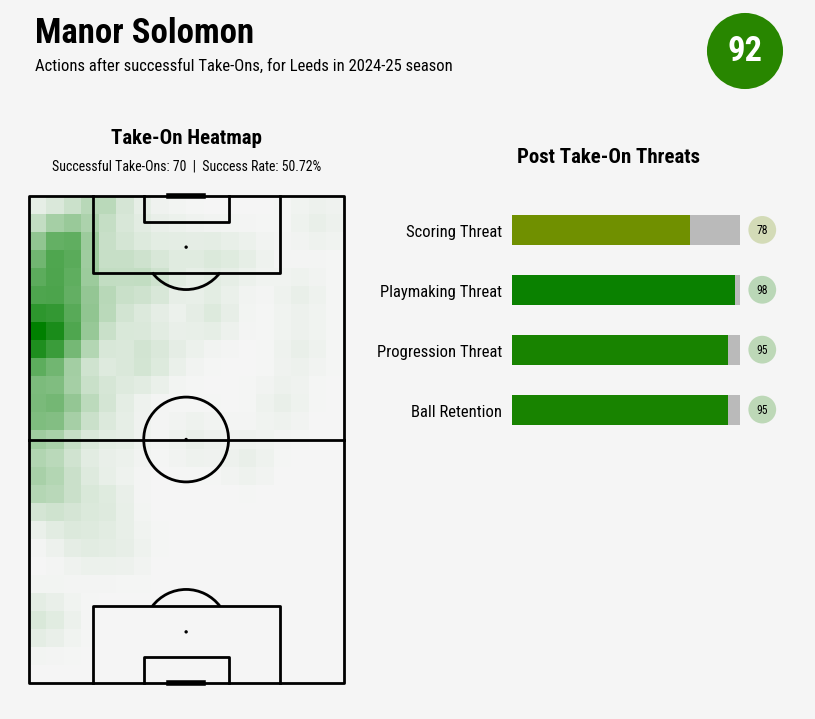

In [66]:
fig, axs = plt.subplots(1,2, figsize=(10, 7), facecolor=bg_color)
pname = 'Manor Solomon'
team_name = 'Leeds'


takeOnEffViz(axs[0], pname, team_name)
overall_rating = rating_viz(axs[1], pname, team_name)

fig.text(0.15, 1.1, f'{pname}', fontproperties=custom_font, fontsize=25, fontweight='bold', color='black', ha='left', va='top')
fig.text(0.15, 1.04, f'Actions after successful Take-Ons, for {team_name} in 2024-25 season', fontproperties=custom_font_thin, fontsize=12, fontweight='bold', color='black', ha='left', va='top')
# fig.text(0.15, 1, 'Percentile among Championship Attackers, using per90 stats', fontproperties=custom_font_thin, fontsize=12, fontweight='bold', color='black', ha='left', va='top')

# ftmb_tid = df_teamNameId[df_teamNameId['teamName']==team_name].teamId.to_list()[0]
# himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
# himage = Image.open(himage)
# ax_himage = add_image(himage, fig, left=0.13, bottom=1, width=0.1, height=0.1)

# Add small square axis at top right corner
corner_ax = fig.add_axes([0.8, 0.99, 0.12, 0.12])

# Create colormap for the scatter point
cmap = mcolors.LinearSegmentedColormap.from_list("", [col1, 
                                                      "orange",
                                                      "green"])
scatter_color = cmap(overall_rating / 100)  # Assuming percentiles are 0-100

# Add scatter point behind the text
corner_ax.scatter(0.5, 0.5, s=3000, c=[scatter_color], edgecolors='None', 
                 linewidth=3, transform=corner_ax.transAxes, zorder=1)

# Add text on top of scatter
corner_ax.text(0.5, 0.5, f'{overall_rating:.0f}', ha='center', va='center', 
               fontproperties=custom_font, fontsize=25, 
               transform=corner_ax.transAxes, color='white', fontweight='bold', zorder=2)

# Remove axis elements
corner_ax.set_xticks([])
corner_ax.set_yticks([])
corner_ax.set_facecolor(bg_color)
for spine in corner_ax.spines.values():
    spine.set_visible(False)

# After Carry Actions

In [18]:
def positive_action(ax, pname):
    dfp = df[df['name']==pname]
    pteam = dfp.teamName.unique()[0]
    # dfteam = df[(df['teamName']==pteam) | (df['oppositionTeamName']==pteam)].reset_index(drop=True)
    dfteam = df[df['teamName']==pteam].reset_index(drop=True)

    pitch = VerticalPitch(pitch_type='uefa', pitch_color=bg_color,  linewidth=2, corner_arcs=True)
    pitch.draw(ax=ax)

    # Successful Pass
    sp = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Successful' 
        ):
            pitch.scatter(row['x'], row['y'], s=25, color=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color=col2, zorder=6, mutation_scale=10, alpha=0.75, linewidth=1)
            ax.add_patch(arrow)
            sp += 1

    # Key Pass
    kp = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'KeyPass' in dfteam.loc[index + 1, 'qualifiers']
        ):
            pitch.scatter(row['x'], row['y'], s=25, color=violet, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=violet, lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color=violet, zorder=6, mutation_scale=10, alpha=0.75, linewidth=1)
            ax.add_patch(arrow)
            kp += 1

    # Assist
    ass = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            'GoalAssist' in dfteam.loc[index + 1, 'qualifiers']
        ):
            pitch.scatter(row['x'], row['y'], s=25, color='green', ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color='green', lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color='green', zorder=6, mutation_scale=10, alpha=0.75, linewidth=1)
            ax.add_patch(arrow)
            ass += 1

    # Shots
    sht = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            dfteam.loc[index + 1, 'type'] in ['MissedShots', 'SavedShot', 'ShotOnPost']
        ):
            pitch.scatter(row['x'], row['y'], s=25, color='orange', ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color='orange', lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='orange', marker='^', ax=ax)
            sht += 1

    # Goals
    gl = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Goal'
        ):
            pitch.scatter(row['x'], row['y'], s=25, color='green', ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color='green', lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='green', marker='^', ax=ax)
            gl += 1

    
            

    ax.set_title('After Carry Positive Impact', fontweight='bold')
    ax_text(34, -4, f'<Successful Pass: {sp}> | <Key Pass: {kp}> | <Assist: {ass}>', ha='center', va='center', 
            highlight_textprops=[{'color': col2}, {'color': violet}, {'color': 'green'}], ax=ax)
    ax_text(34, -8, f'<Shots: {sht}> | <Goals: {gl}>', ha='center', va='center', 
            highlight_textprops=[{'color': 'orange'}, {'color': 'green'}], ax=ax)
    
    return

def negative_action(ax, pname):
    dfp = df[df['name']==pname]
    pteam = dfp.teamName.unique()[0]
    # dfteam = df[(df['teamName']==pteam) | (df['oppositionTeamName']==pteam)].reset_index(drop=True)
    dfteam = df[df['teamName']==pteam].reset_index(drop=True)

    pitch = VerticalPitch(pitch_type='uefa', pitch_color=bg_color,  linewidth=2, corner_arcs=True)
    pitch.draw(ax=ax)

    # Unsuccessful Pass
    up = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            dfteam.loc[index + 1, 'type'] == 'Pass' and
            dfteam.loc[index + 1, 'outcomeType'] == 'Unsuccessful' 
        ):
            pitch.scatter(row['x'], row['y'], s=25, color=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            arrow = patches.FancyArrowPatch((dfteam.loc[index + 1, 'y'], dfteam.loc[index + 1, 'x']), (dfteam.loc[index + 1, 'endY'], 
                                             dfteam.loc[index + 1, 'endX']), arrowstyle='->', color=col1, zorder=6, mutation_scale=10, alpha=0.75, linewidth=1)
            ax.add_patch(arrow)
            up += 1

    # Possession Lost
    pl = 0
    for index, row in dfteam.iterrows():
        if (
            row['name'] == pname and 
            row['type'] == 'Carry' and 
            row['outcomeType'] == 'Successful' and 
            index + 1 < len(dfteam) and  
            dfteam.loc[index + 1, 'name'] == pname and
            (
                dfteam.loc[index + 1, 'type'] == 'Dispossessed' or 
                dfteam.loc[index + 1, 'type'] == 'BallTouch'
            )
        ):
            pitch.scatter(row['x'], row['y'], s=25, color=col2, ax=ax)
            pitch.lines(row['x'], row['y'], dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], color=col2, lw=0.75, ls='--', ax=ax)
            pitch.scatter(dfteam.loc[index + 1, 'x'], dfteam.loc[index + 1, 'y'], s=100, color='orange', marker='x', ax=ax)
            pl += 1

    ax.set_title('After Carry Negative Impact', fontweight='bold')
    ax_text(34, -4, f'<Unsuccessful Pass: {up}> | <Possession Lost: {pl}>', ha='center', va='center', 
            highlight_textprops=[{'color': col1}, {'color': 'orange'}], ax=ax)
    ftmb_tid = df_teamNameId[df_teamNameId['teamName']==pteam].teamId.to_list()[0]
    return ftmb_tid

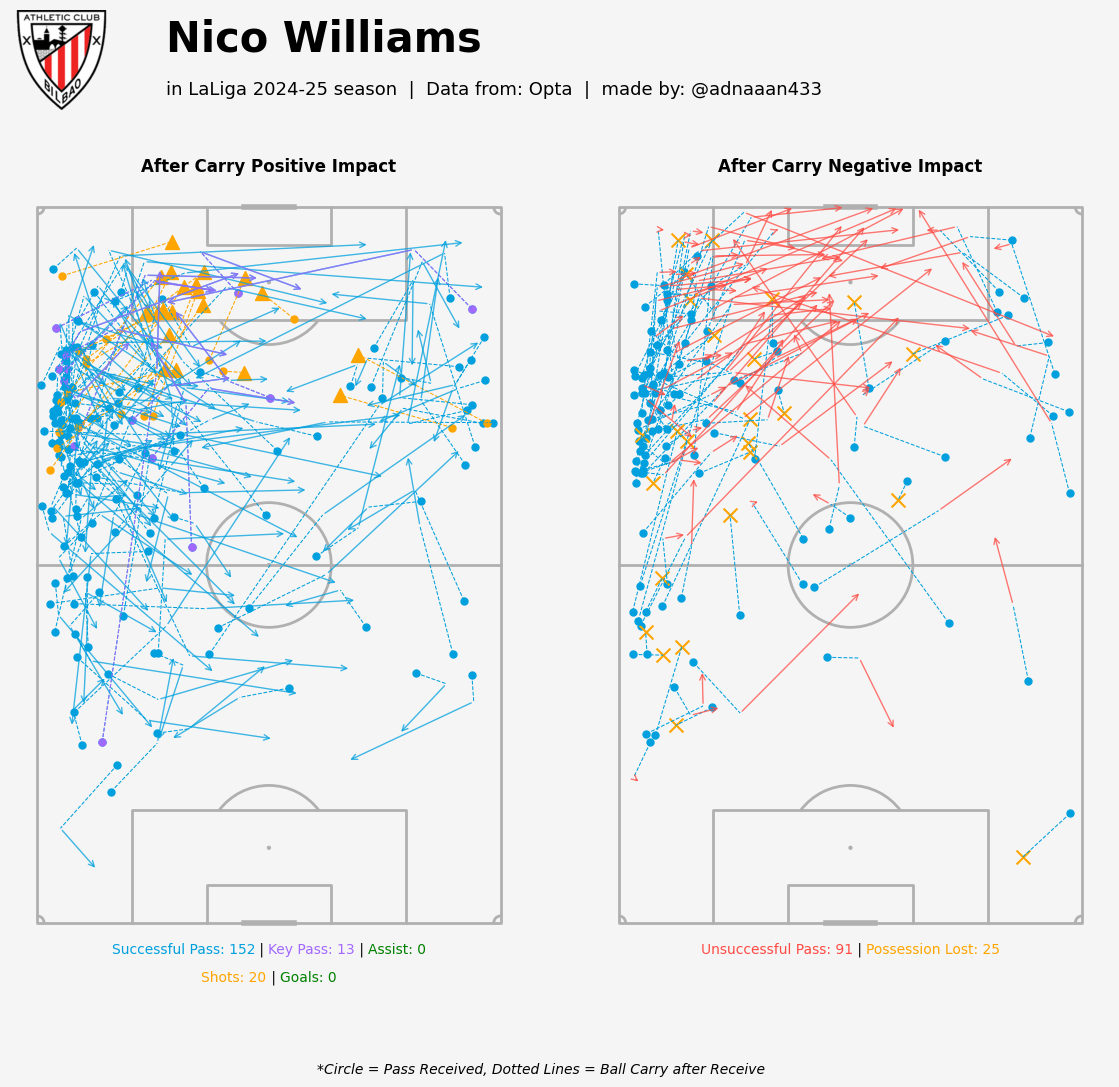

In [19]:
fig,axs = plt.subplots(1,2, figsize=(15,10), facecolor=bg_color)
positive_action(axs[0], 'Nico Williams')
ftmb_tid = negative_action(axs[1], 'Nico Williams')
fig.subplots_adjust(wspace=0.001)

fig.text(0.25, 1.02, 'Nico Williams', fontsize=30, fontweight='bold', va='center')
fig.text(0.25, 0.97, 'in LaLiga 2024-25 season  |  Data from: Opta  |  made by: @adnaaan433', fontsize=13, va='center')
# fig.text(0.25, 0.97, 'Data from: Opta | made by: @adnaaan433', fontsize=13, va='center')

fig.text(0.5, -0.01, '*Circle = Pass Received, Dotted Lines = Ball Carry after Receive', fontstyle='italic', ha='center', va='center')

himage = urlopen(f"https://images.fotmob.com/image_resources/logo/teamlogo/{ftmb_tid}.png")
himage = Image.open(himage)
ax_himage = add_image(himage, fig, left=0.13, bottom=0.95, width=0.1, height=0.1)